# Geometry n(t) comparison

Rebuilds the ranking / crossover-stability analysis from the React tool as a notebook.

Set `CSV_PATH` below to a CSV with columns `geometry, t, n` (case-insensitive, same
matching rule as the original `papaparse`-based upload handler). Leave it as `None`
to use the synthetic demo curves instead.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import io

%matplotlib inline

PRESET_TIMES = [1000, 15000, 60000]



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "savefig.dpi": 300,
    "figure.dpi": 150,
})

## CSV parser (mirrors the `papaparse` header-matching logic from the React component)

In [2]:
# ---- Formatters (mirror fmtTime/fmtMol/fmtVol/fmtArea/fmtR/fmtH) ----
def fmt_time(t):
    return f"{t/1000:.0f}k s" if t >= 1000 and t % 1000 == 0 else (
        f"{t/1000:.1f}k s" if t >= 1000 else f"{t:g} s")

def fmt_mol(v):
    return "—" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.2e} mol"

def fmt_vol(v):
    return "—" if v is None else f"{v*1e13:.2f} ×10⁻¹³ m³"

def fmt_area(v):
    return "—" if v is None else f"{v*1e8:.3f} ×10⁻⁸ m²"

def fmt_r(r): return f"{r*1e6:.1f} µm"
def fmt_h(h): return f"{h*1e6:.0f} µm"

In [3]:
# ---- Parsers (ports of parseNumericCell / findColumnIndex / parseCOMSOLTxt / parseVolumeCsv) ----
def parse_numeric_cell(value):
    if value is None:
        return None
    cleaned = str(value).strip()
    if not cleaned or cleaned.lower() in ("-", "--", "null", "nan", "none"):
        return None
    try:
        return float(cleaned)
    except ValueError:
        return None


def find_column_index(headers, candidates):
    if not headers:
        return -1
    norm = lambda s: re.sub(r"[^a-z0-9]+", "_", str(s).lower())
    normalized_headers = [norm(h) for h in headers]

    # Pass 1: exact match only (handles short candidates like "t", "R", "H" safely)
    for candidate in candidates:
        nc = norm(candidate)
        for i, h in enumerate(normalized_headers):
            if h == nc:
                return i

    # Pass 2: substring match, but only for candidates long enough to be unambiguous
    for candidate in candidates:
        nc = norm(candidate)
        if len(nc) < 3:
            continue
        for i, h in enumerate(normalized_headers):
            if nc in h or h in nc:
                return i

    return -1


def parse_comsol_txt(text: str):
    """Whitespace-delimited COMSOL .txt export -> list of (R, H, t, value) tuples."""
    rows = []
    headers = None

    for raw_line in text.replace("\r", "").split("\n"):
        line = raw_line.strip()
        if not line:
            continue

        if line.startswith("%"):
            header_text = line[1:].strip()
            if re.search(r"(R_texture|H_texture|H_cone|Total moles|intopA|intopV|Volume|value)",
                         header_text, re.I):
                headers = [h.strip() for h in re.split(r"\s{2,}", header_text) if h.strip()]
            continue

        vals = [parse_numeric_cell(v) for v in line.split()]
        if len(vals) < 4:
            continue

        r_idx = find_column_index(headers, ["R_texture", "R"])
        h_idx = find_column_index(headers, ["H_texture", "H_cone", "H"])
        t_idx = find_column_index(headers, ["t", "time"])
        v_idx = find_column_index(headers, ["moles", "intopA", "intopV", "Volume", "value"])

        R = H = t = value = None
        if min(r_idx, h_idx, t_idx, v_idx) >= 0:
            R, H, t, value = vals[r_idx], vals[h_idx], vals[t_idx], vals[v_idx]
        else:
            # fallback: simple 4-column cone-style layout (H, R, t, value)
            if all(v is not None for v in vals[:4]):
                if vals[0] < 1e-4 and vals[1] < 1e-4 and vals[2] >= 0:
                    H, R, t, value = vals[0], vals[1], vals[2], vals[3]

        if None not in (R, H, t, value):
            rows.append((R, H, t, value))

    return rows


def parse_volume_csv(text: str):
    """Pivoted volume .csv export -> list of {R, H, V_unit} dicts."""
    entries = []
    headers = None

    for raw_line in text.replace("\r", "").split("\n"):
        line = raw_line.strip()
        if not line:
            continue

        if line.startswith("%"):
            header_text = line[1:].strip()
            if re.search(r"(R_texture|H_texture|H_cone|Volume|intopV|intopA)", header_text, re.I):
                headers = next(csv.reader([header_text]))
            continue

        row = next(csv.reader([line]))
        vals = [parse_numeric_cell(v) for v in row]
        if len(vals) < 4:
            continue

        r_idx = find_column_index(headers, ["R_texture", "R"])
        h_idx = find_column_index(headers, ["H_texture", "H_cone", "H"])
        v_idx = find_column_index(headers, ["Volume", "intopV", "intopA", "value"])

        R = vals[r_idx] if r_idx >= 0 else vals[0]
        H = vals[h_idx] if h_idx >= 0 else vals[1]
        V_unit = vals[v_idx] if v_idx >= 0 else vals[3]

        if None not in (R, H, V_unit):
            entries.append({"R": R, "H": H, "V_unit": V_unit})

    return entries

In [4]:
# ---- Geometry keys / interpolation ----
def geo_key(R, H): return (R, H)
def geo_label(R, H): return f"R={fmt_r(R)} H={fmt_h(H)}"

def interp_at(points, t_query):
    """points: list of (t, n) tuples, sorted by t."""
    if not points:
        return None
    ts = [p[0] for p in points]
    ns = [p[1] for p in points]
    return float(np.interp(t_query, ts, ns))

In [5]:
# ---- Build series from raw uptake rows ----
def build_series(uptake_rows):
    series = {}
    for R, H, t, n in uptake_rows:
        key = geo_key(R, H)
        series.setdefault(key, {"R": R, "H": H, "label": geo_label(R, H), "points": []})
        series[key]["points"].append((t, n))
    for g in series.values():
        g["points"].sort(key=lambda p: p[0])
    all_r = sorted({g["R"] for g in series.values()})
    all_h = sorted({g["H"] for g in series.values()})
    return series, all_r, all_h

In [6]:
# ---- Ranking + crossover (same logic as `ranking` / `presetRankings` / `rankingStable`) ----
def rank_at(series, vol_map, area_map, t_process):
    rows = []
    for key, g in series.items():
        n_t = interp_at(g["points"], t_process)
        n_eq = g["points"][-1][1] if g["points"] else None
        rows.append({
            "key": key, "label": g["label"], "R": g["R"], "H": g["H"],
            "n_t": n_t, "n_eq": n_eq,
            "V_unit": vol_map.get(key), "intopA": area_map.get(key),
            "pct": (n_t / n_eq * 100) if (n_t and n_eq) else None,
        })
    rows.sort(key=lambda r: r["n_t"] if r["n_t"] is not None else -np.inf, reverse=True)
    return rows


def check_stability(series, preset_times=PRESET_TIMES):
    orders = {}
    for t in preset_times:
        ranked = sorted(series.keys(),
                         key=lambda k: interp_at(series[k]["points"], t) or -np.inf,
                         reverse=True)
        orders[t] = ranked
    stable = len(set(tuple(o) for o in orders.values())) == 1
    return stable, orders

In [7]:
# ---- Plot: color = R, dash style = H (mirrors R_COLORS / H_DASHES) ----
R_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948"]
H_DASHES = [None, (6, 3), (2, 2)]  # matplotlib linestyle equivalents of "0"/"6 3"/"2 2"

def plot_series(series, all_r, all_h, t_process, out_path=None, xlim=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for key, g in series.items():
        ts = [p[0] for p in g["points"] if p[0] > 0]
        ns = [p[1] for t, p in zip((p[0] for p in g["points"]), g["points"]) if t > 0]
        r_i = all_r.index(g["R"]) % len(R_COLORS)
        h_i = all_h.index(g["H"]) % len(H_DASHES)
        dash = H_DASHES[h_i]
        ax.plot(ts, ns, color=R_COLORS[r_i],
                linestyle="-" if dash is None else (0, dash),
                linewidth=1.6, label=g["label"])
        
    ax.axvline(t_process, color="#C1502E", linestyle="--", linewidth=1.3)
    ax.set_xlim(0, xlim if xlim else max(p[0] for g in series.values() for p in g["points"]))
    ax.set_xlabel("t (s, log scale)")
    ax.set_ylabel("n(t) — mol CO₂")
    ax.set_title("Microtexture comparison — color=R, dash=H")
    ax.grid(True, which="both", linewidth=0.4, alpha=0.5)
    ax.legend(fontsize=7, frameon=False, ncol=2)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150)
    plt.show()

In [8]:
def plot_series_win(series, all_r, all_h, t_process, out_path=None, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # find the winner at t_process
    ranking = rank_at(series, vol_map, area_map, t_process)
    winner_label = ranking[0]["label"]  # adjust to however rank_at structures this
    
    for key, g in series.items():
        ts = [p[0] for p in g["points"] if p[0] > 0]
        ns = [p[1] for t, p in zip((p[0] for p in g["points"]), g["points"]) if t > 0]
        is_winner = g["label"] == winner_label
        ax.plot(ts, ns,
                color="#e34948" if is_winner else "#cccccc",
                linewidth=2.5 if is_winner else 0.8,
                alpha=1.0 if is_winner else 0.5,
                zorder=10 if is_winner else 1,
                label=g["label"] if is_winner else None)  # only label the winner
    ax.axvline(t_process, color="#C1502E", linestyle="--", linewidth=1.3)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    ax.set_xlabel("t (s)")
    ax.set_ylabel("n(t) — mol CO₂")
    ax.set_title(f"Winner at t={t_process}s: {winner_label}")
    ax.legend(fontsize=9, frameon=False)
    fig.tight_layout()
    plt.show()

In [9]:
def leadership_timeline_report(series, t_start=1, t_end=200000, n_steps=400,
                                family_name=None, fmt_time=None):
    if fmt_time is None:
        def fmt_time(t):
            if t >= 1000:
                return f"{t/1000:.1f}k s"
            return f"{t:.0f} s"

    t_end_padded = t_end * 1.25
    time_grid = np.logspace(np.log10(t_start), np.log10(t_end_padded), n_steps)

    leaders = []
    for t in time_grid:
        best_label, best_val = None, -np.inf
        for key, g in series.items():
            pts = sorted(g["points"], key=lambda p: p[0])
            ts = [p[0] for p in pts]
            ns = [p[1] for p in pts]
            if not ts or t < ts[0]:
                continue
            val = np.interp(t, ts, ns)
            if val > best_val:
                best_val, best_label = val, g["label"]
        leaders.append(normalize_label(best_label))

    segments = []
    seg_start = time_grid[0]
    current = leaders[0]
    for t, lab in zip(time_grid[1:], leaders[1:]):
        if lab != current:
            segments.append((seg_start, t, current))
            seg_start, current = t, lab
    segments.append((seg_start, time_grid[-1], current))

    # clip the last segment's reported end back to the real t_end —
    # time_grid[-1] is t_end_padded, which is not a real reporting value
    last_start, _, last_lab = segments[-1]
    segments[-1] = (last_start, t_end, last_lab)

    fig, (ax, ax_table) = plt.subplots(
        2, 1, figsize=(10, 3.8),
        gridspec_kw={"height_ratios": [2, 1.1], "hspace": 0.5}
    )

    for start, end, lab in segments:
        ax.barh(0, end - start, left=start, height=0.6,
                color=get_color(lab), edgecolor="white", linewidth=0.5)

    for i, (start, end, lab) in enumerate(segments):
        mid = np.sqrt(start * end) if start > 0 else end / 2
        above = (i % 2 == 0)
        y_text = 0.5 if above else -0.5
        va = "bottom" if above else "top"
        ax.plot([mid, mid], [0.3 if above else -0.3, y_text * 0.8],
                color="gray", linewidth=0.6, zorder=1)
        lab_two_line = lab.replace(" H=", "\nH=") if " H=" in lab else lab
        ax.text(mid, y_text, lab_two_line, ha="center", va=va,
                 fontsize=9, linespacing=1.3)

    ax.set_xscale("log")
    ax.set_xlim(t_start, t_end)
    ax.set_ylim(-0.85, 0.85)
    ax.set_yticks([])
    ax.set_xlabel("t (s, log scale)")  # real xlabel, tied to the real axis
    title = "Leading texture over time" if family_name is None else f"Leading {family_name} geometry by early-time uptake"
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # --- legend/key table underneath: geometry + color + duration only ---
    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(0, 1)
    ax_table.axis("off")

    n = len(segments)
    col_w = 1.0 / n
    for i, (start, end, lab) in enumerate(segments):
        x0 = i * col_w
        ax_table.add_patch(plt.Rectangle((x0 + 0.02*col_w, 0.5), 0.2*col_w, 0.4,
                                          color=get_color(lab), transform=ax_table.transAxes))
        ax_table.text(x0 + 0.3*col_w, 0.7, lab.replace(" H=", "\nH="),
                      fontsize=8, va="center", ha="left", linespacing=1.2,
                      transform=ax_table.transAxes)
        duration_str = f"{fmt_time(start)} \u2192 {fmt_time(end)}"
        ax_table.text(x0 + 0.02*col_w, 0.15, duration_str,
                      fontsize=8, va="center", ha="left",
                      transform=ax_table.transAxes)

    fig.tight_layout()
    return fig, (ax, ax_table), segments

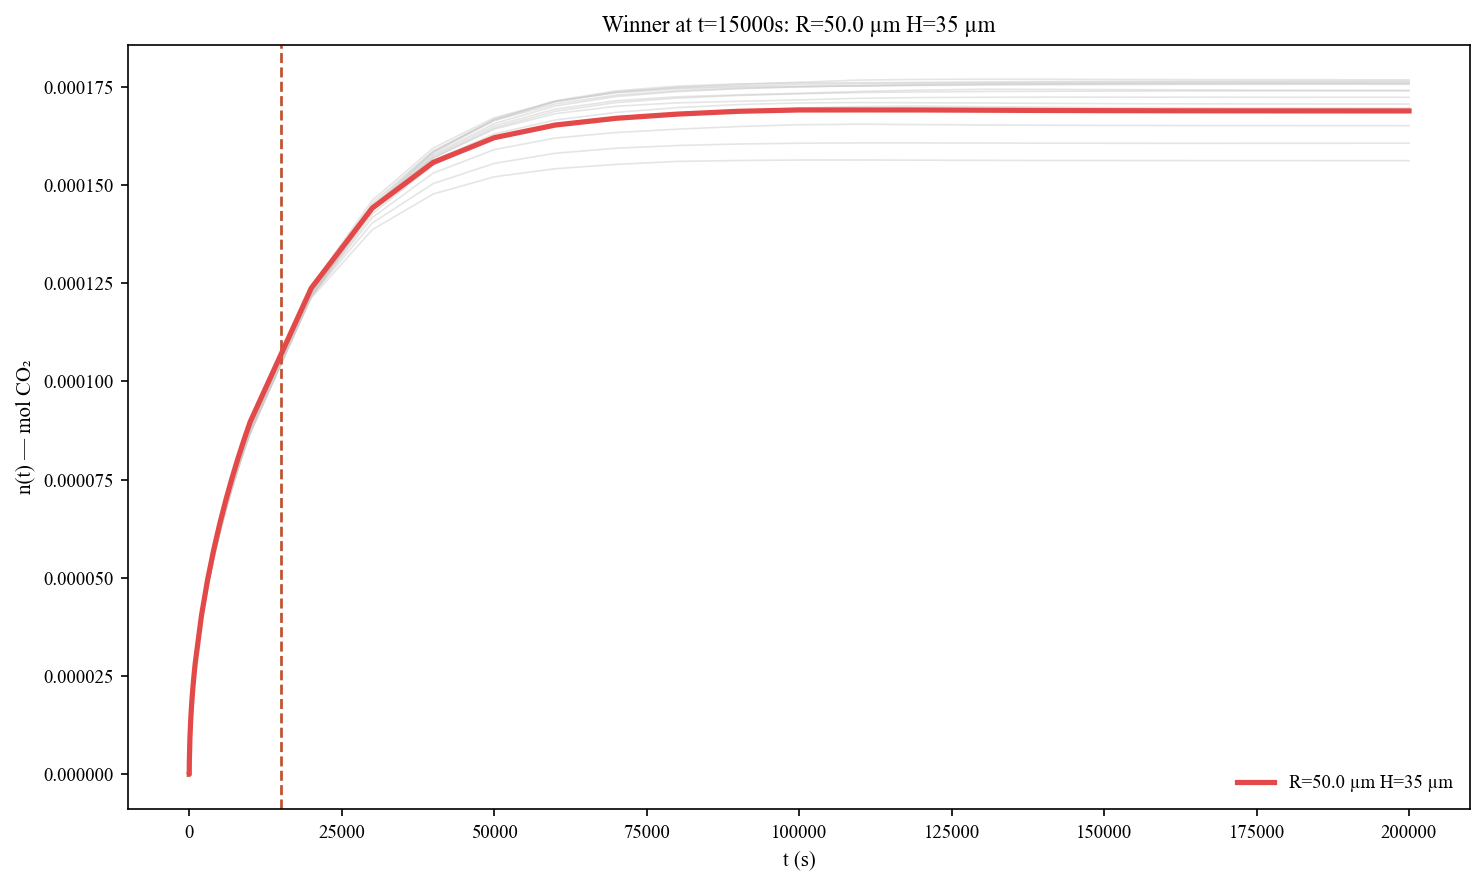

In [10]:

# ---- Example usage ----
uptake_text = open("uptake-file-cones-v1.txt").read()
volume_text = open("volume-file-cones-v1.csv").read()

uptake_text = open("data/cone-recessed-uptake.txt").read()
volume_text = open("data/cone-recessed-volume.csv").read()

uptake_rows = parse_comsol_txt(uptake_text)
# print(uptake_rows)
volume_entries = parse_volume_csv(volume_text)
vol_map = {geo_key(e["R"], e["H"]): e["V_unit"] for e in volume_entries}
area_map = {}  # same pattern with parse_comsol_txt on the area file
    
series, all_r, all_h = build_series(uptake_rows)
ranking = rank_at(series, vol_map, area_map, t_process=15000)
stable, orders = check_stability(series)
plot_series_win(series, all_r, all_h, t_process=15000)

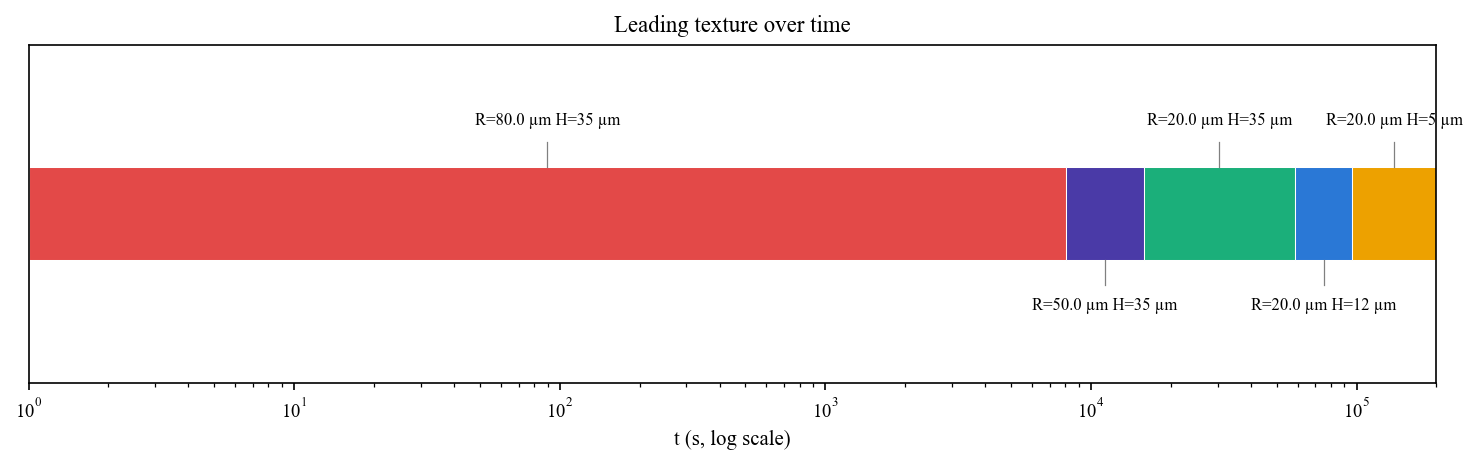

1 s → 8.1k s: R=80.0 µm H=35 µm
8.1k s → 15.8k s: R=50.0 µm H=35 µm
15.8k s → 58.8k s: R=20.0 µm H=35 µm
58.8k s → 96.0k s: R=20.0 µm H=12 µm
96.0k s → 200.0k s: R=20.0 µm H=5 µm


In [24]:
segments = leadership_timeline(series, t_start=1, t_end=200000)
for start, end, lab in segments:
    print(f"{fmt_time(start)} → {fmt_time(end)}: {lab}")

C:\Users\alonzo\AppData\Local\Temp\ipykernel_16528\1786377937.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


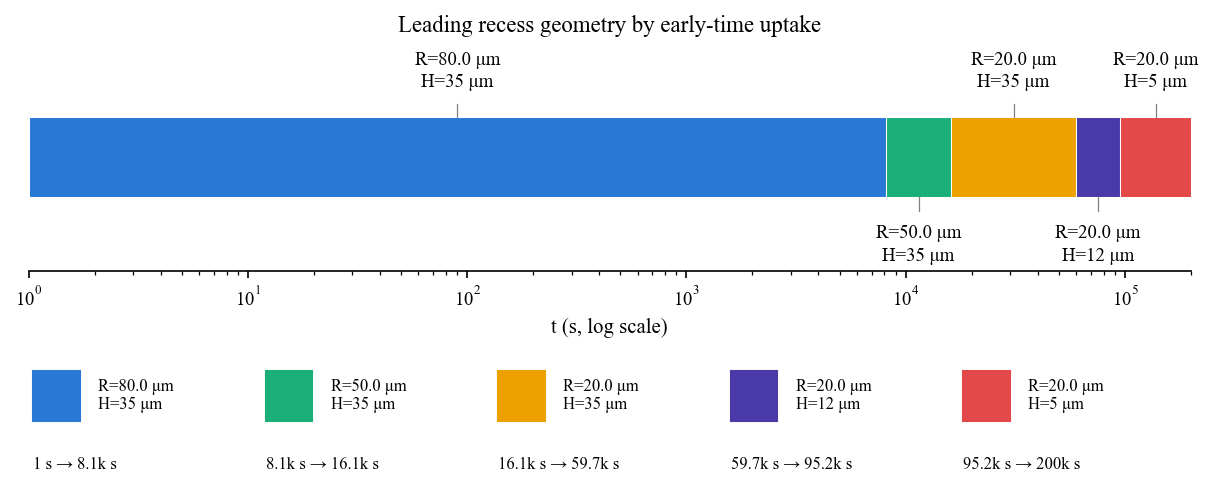

In [37]:
fig, axes, segments = leadership_timeline_report(
    series, t_start=1, t_end=200000, family_name="recess", fmt_time=fmt_time
)
fig.savefig("leadership_timeline_recess.pdf", bbox_inches="tight")

FloatLogSlider(value=15000.0, description='t_process', layout=Layout(width='600px'), max=5.3, readout_format='…

Output()

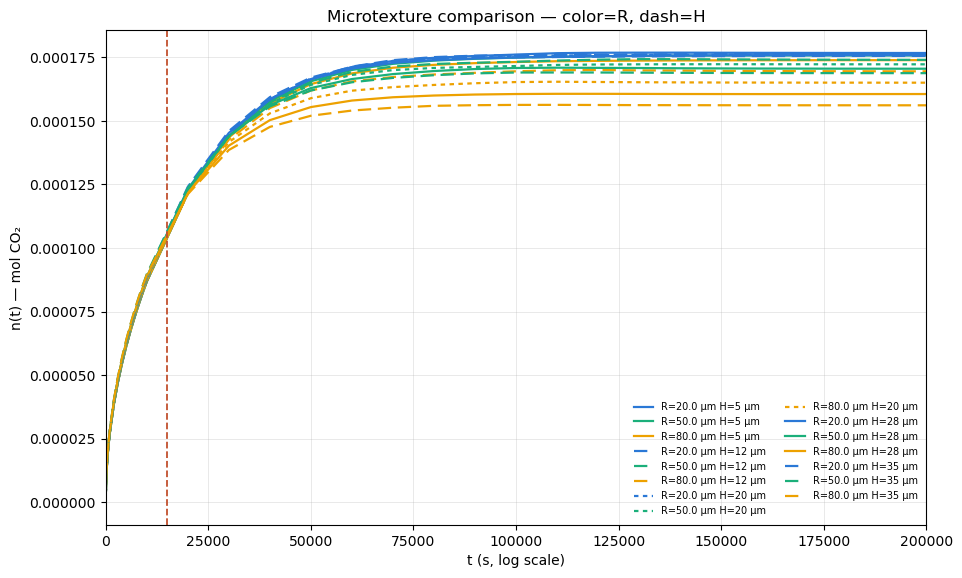

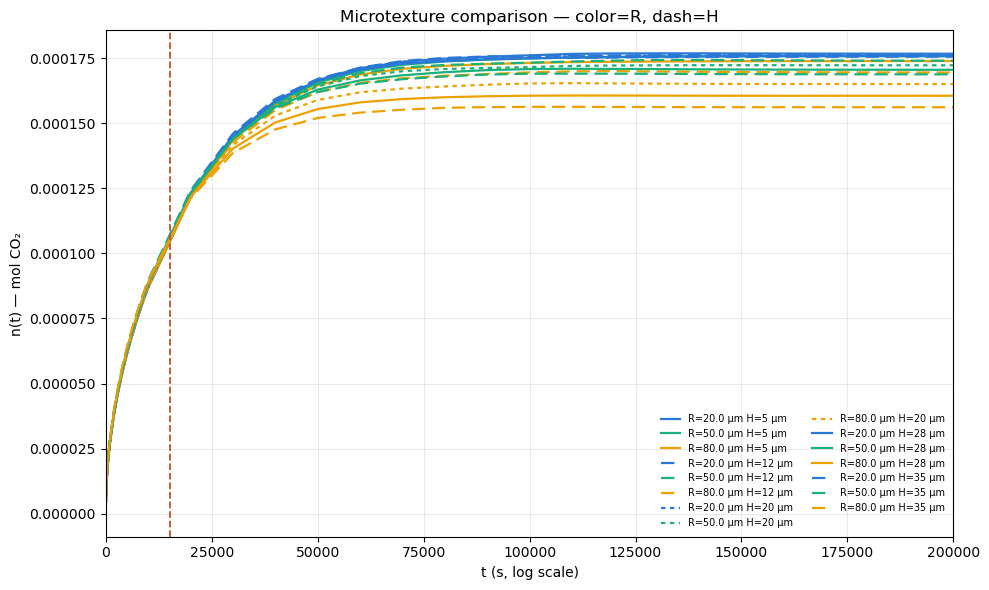

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

t_slider = widgets.FloatLogSlider(
    value=15000, base=10, min=0, max=5.3, step=0.01,
    description="t_process", readout_format=".0f",
    layout=widgets.Layout(width="600px"),
)
preset_buttons = widgets.HBox([
    widgets.Button(description=fmt_time(pt)) for pt in PRESET_TIMES
])
out = widgets.Output()

_last_rendered = {"t": None}  # guard against duplicate renders for the same value

def render(t_process):
    if _last_rendered["t"] == t_process:
        return  # skip redundant re-render (e.g. frontend value-snap echo)
    _last_rendered["t"] = t_process

    with out:
        clear_output(wait=False)  # wait=False: clear immediately, no stale frame
        ranking = rank_at(series, vol_map, area_map, t_process)
        df = pd.DataFrame(ranking)
        df["n_t"] = df["n_t"].apply(fmt_mol)
        df["n_eq"] = df["n_eq"].apply(fmt_mol)
        df["pct"] = df["pct"].apply(lambda p: f"{p:.0f}%" if p is not None else "—")
        display(df[["label", "R", "H", "n_t", "n_eq", "pct"]])

        fig = plot_series(series, all_r, all_h, t_process)  # see note below
        plt.show()
        plt.close(fig)  # prevent duplicate/lingering figure refs

def on_slider_change(change):
    render(change["new"])

def make_preset_handler(t):
    def handler(_):
        t_slider.value = t
    return handler

t_slider.observe(on_slider_change, names="value")
for btn, pt in zip(preset_buttons.children, PRESET_TIMES):
    btn.on_click(make_preset_handler(pt))

display(t_slider, preset_buttons, out)
render(t_slider.value)